# K-Nearest Neighbours

In [1]:
from pandas import read_csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.figsize']=(10,5)
plt.rcParams['figure.dpi']=150
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report,accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV


In [2]:
df=pd.read_csv("Zoo.csv")

In [3]:
df

,animal name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,wallaby,1,0,0,1,0,0,0,1,1,1,0,0,2,1,0,1,1
97,wasp,1,0,1,0,1,0,0,0,0,1,1,0,6,0,0,0,6
98,wolf,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
99,worm,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,7


In [4]:
df.shape

(101, 18)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   animal name  101 non-null    object
 1   hair         101 non-null    int64 
 2   feathers     101 non-null    int64 
 3   eggs         101 non-null    int64 
 4   milk         101 non-null    int64 
 5   airborne     101 non-null    int64 
 6   aquatic      101 non-null    int64 
 7   predator     101 non-null    int64 
 8   toothed      101 non-null    int64 
 9   backbone     101 non-null    int64 
 10  breathes     101 non-null    int64 
 11  venomous     101 non-null    int64 
 12  fins         101 non-null    int64 
 13  legs         101 non-null    int64 
 14  tail         101 non-null    int64 
 15  domestic     101 non-null    int64 
 16  catsize      101 non-null    int64 
 17  type         101 non-null    int64 
dtypes: int64(17), object(1)
memory usage: 14.3+ KB


In [6]:
df.isna().sum()

animal name    0
hair           0
feathers       0
eggs           0
milk           0
airborne       0
aquatic        0
predator       0
toothed        0
backbone       0
breathes       0
venomous       0
fins           0
legs           0
tail           0
domestic       0
catsize        0
type           0
dtype: int64

In [7]:
df.duplicated().sum()

0

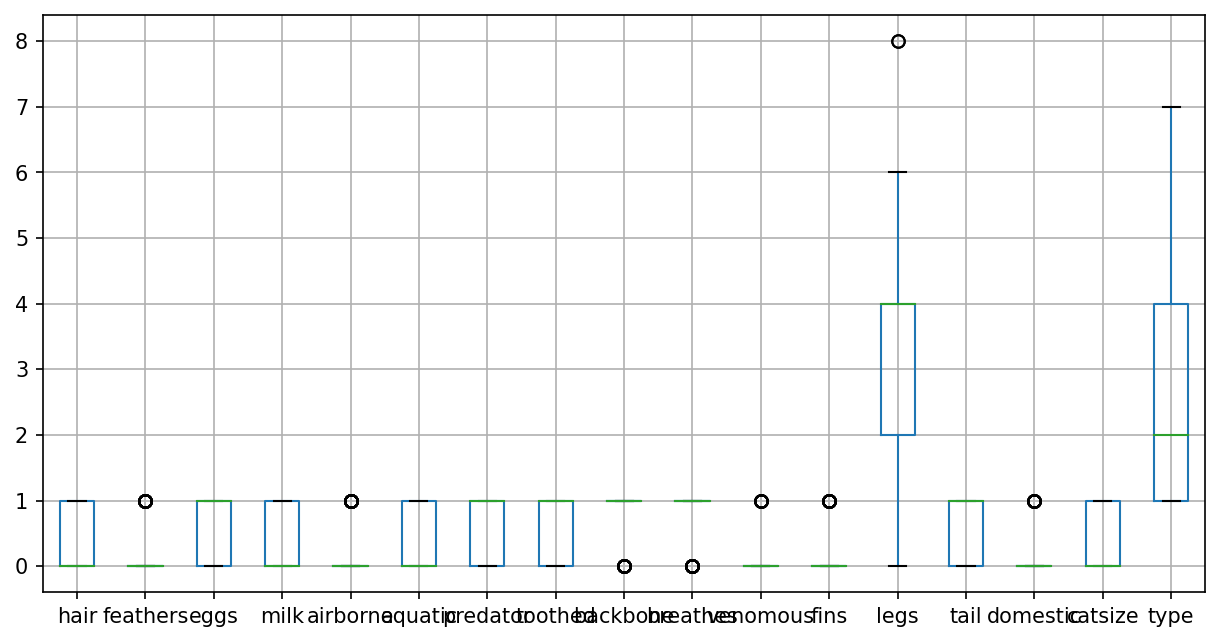

In [8]:
df.boxplot()
plt.tight_layout
plt.show()

In [9]:
dff=df.drop(columns=['animal name'])

In [10]:
dff.head().shape

(5, 17)

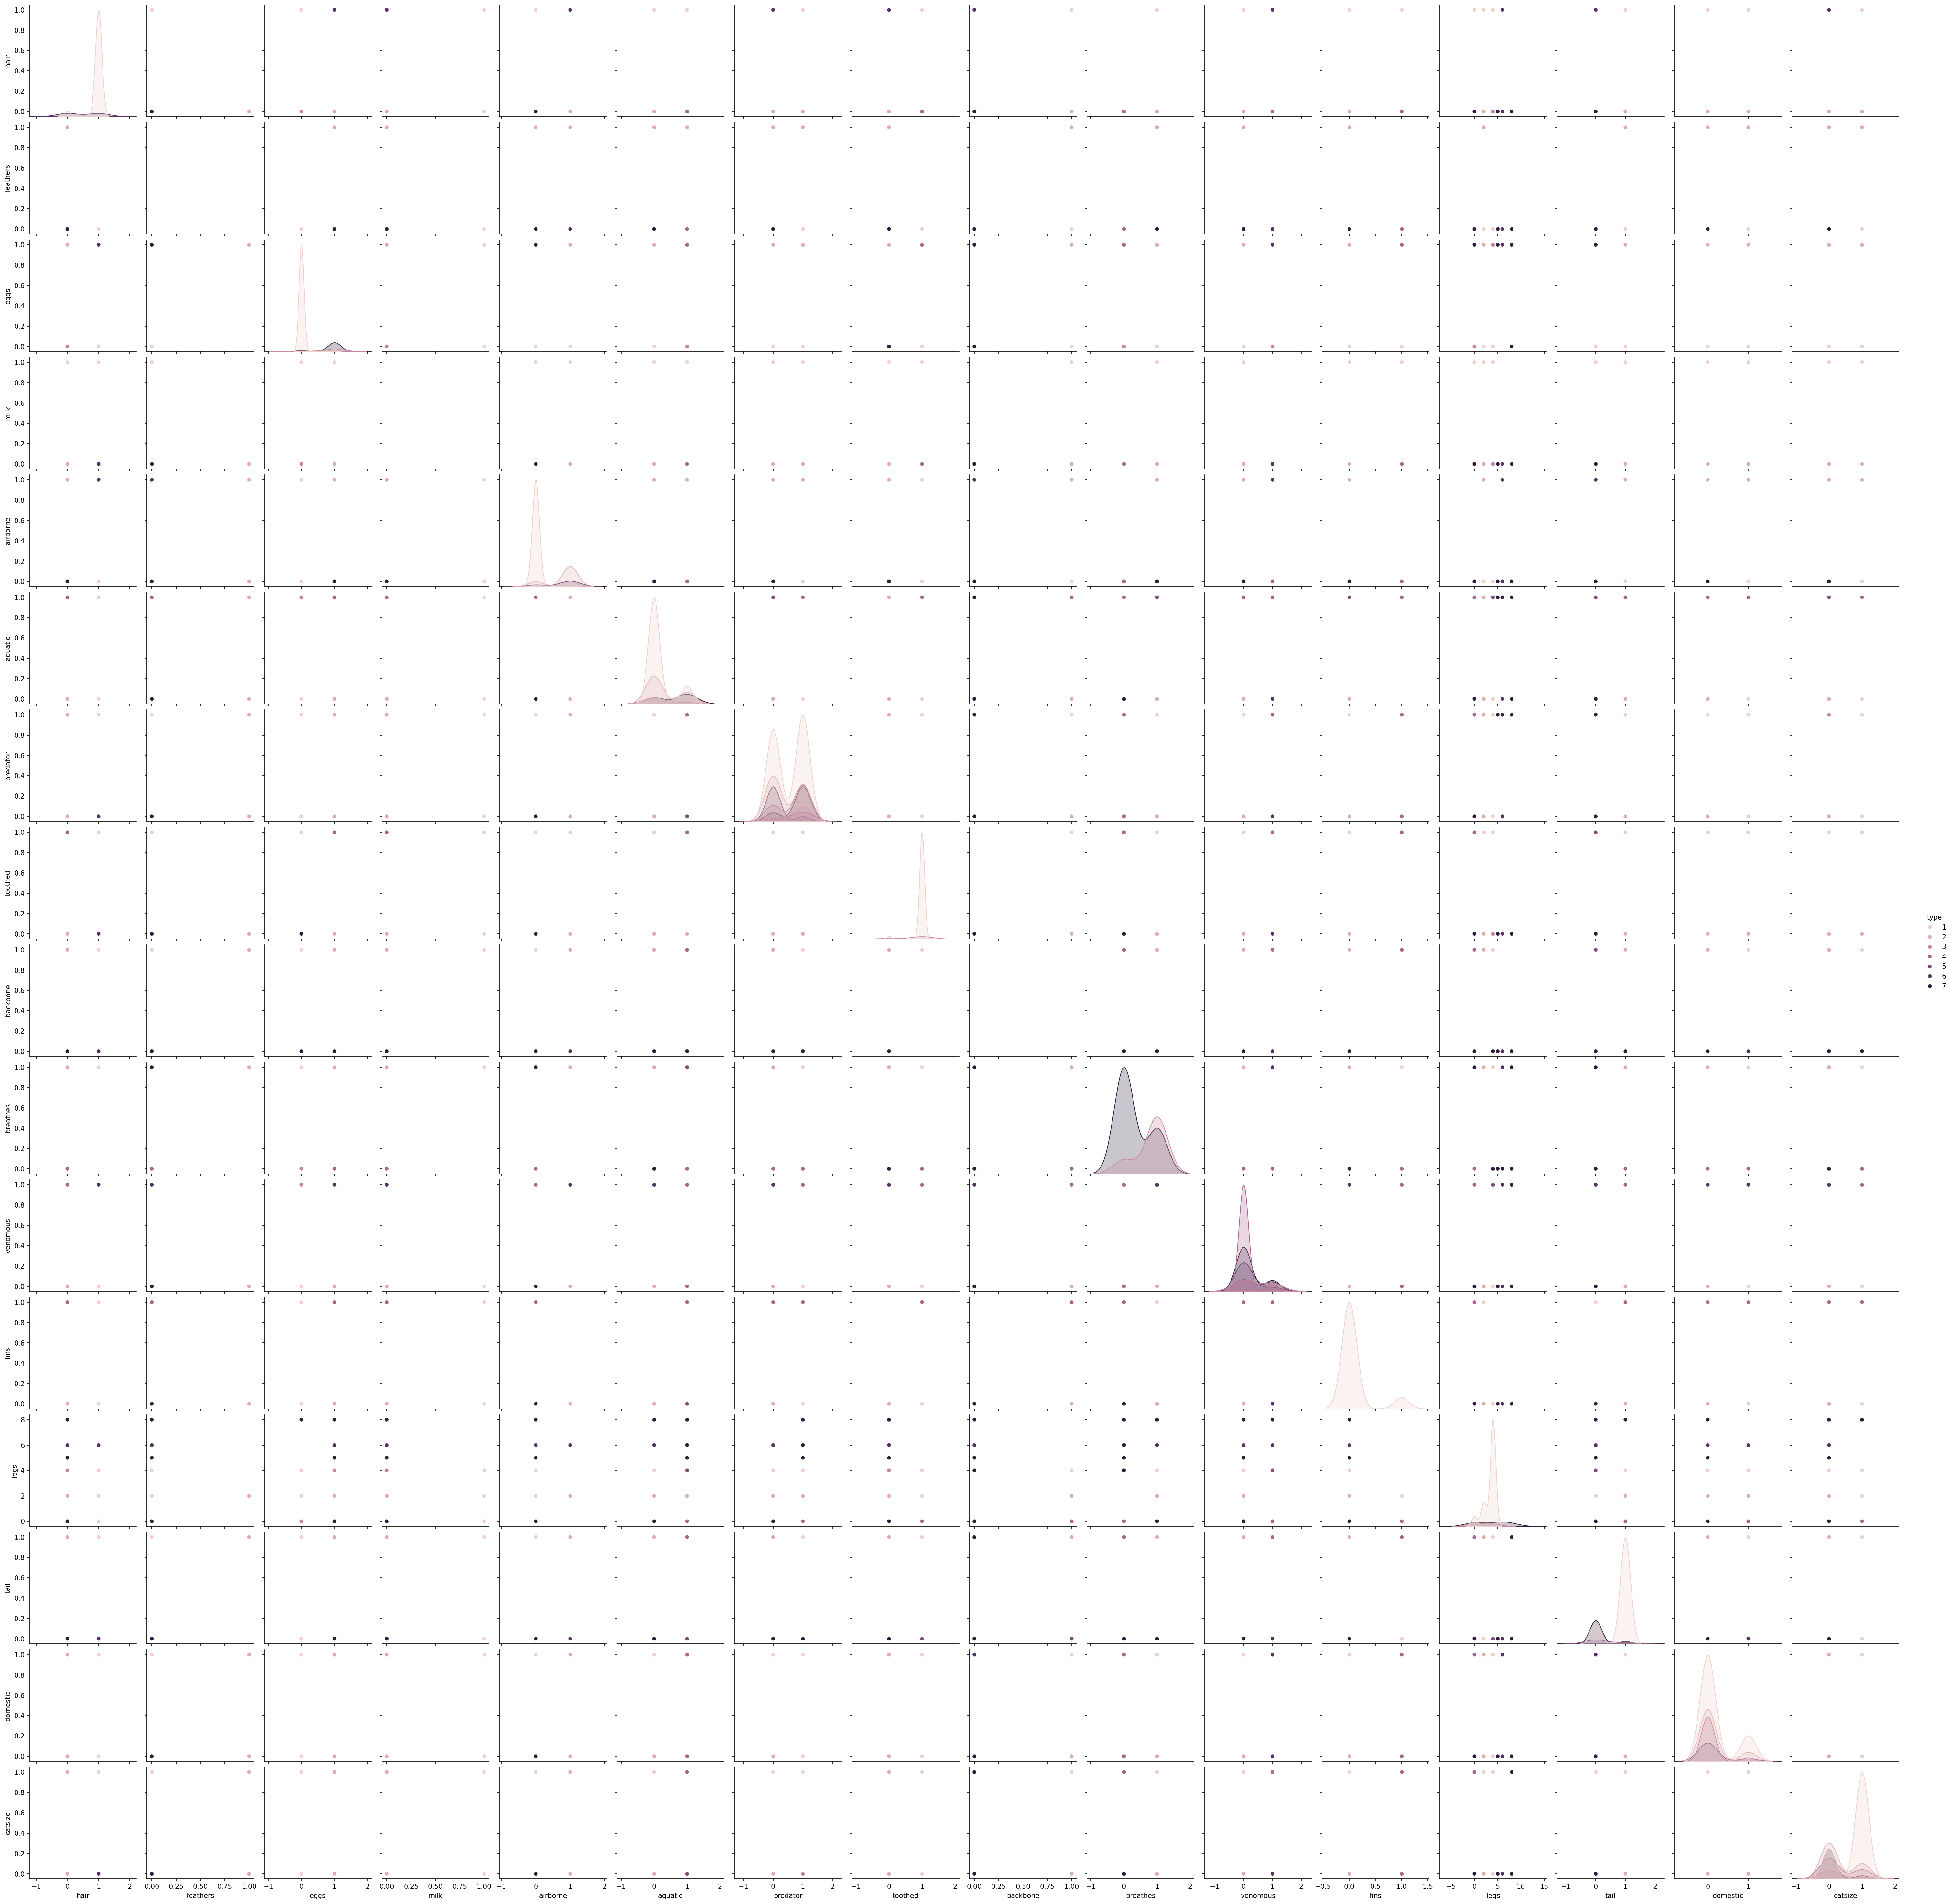

In [11]:
sns.pairplot(dff,hue='type')
plt.show()

In [12]:
x=dff.iloc[:,0:-1]
y=dff['type']

In [13]:
x

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize
0,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1
1,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1
2,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0
3,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1
4,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,1,0,0,1,0,0,0,1,1,1,0,0,2,1,0,1
97,1,0,1,0,1,0,0,0,0,1,1,0,6,0,0,0
98,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1
99,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0


In [14]:
y

0      1
1      1
2      4
3      1
4      1
      ..
96     1
97     6
98     1
99     7
100    2
Name: type, Length: 101, dtype: int64

In [15]:
sc=StandardScaler()
x=sc.fit_transform(x)
x

array([[ 1.16139451, -0.49690399, -1.18522652, ..., -1.69841555,
        -0.38435306,  1.13818037],
       [ 1.16139451, -0.49690399, -1.18522652, ...,  0.58878406,
        -0.38435306,  1.13818037],
       [-0.86103386, -0.49690399,  0.84372057, ...,  0.58878406,
        -0.38435306, -0.87859537],
       ...,
       [ 1.16139451, -0.49690399, -1.18522652, ...,  0.58878406,
        -0.38435306,  1.13818037],
       [-0.86103386, -0.49690399,  0.84372057, ..., -1.69841555,
        -0.38435306, -0.87859537],
       [-0.86103386,  2.01246118,  0.84372057, ...,  0.58878406,
        -0.38435306, -0.87859537]])

In [16]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)


In [17]:
model=KNeighborsClassifier(n_neighbors=10,metric='euclidean')
results=model.fit(xtrain,ytrain)

In [18]:
results

KNeighborsClassifier(metric='euclidean', n_neighbors=10)

In [19]:
y_pred=results.predict(xtest)

In [20]:
y_pred

array([1, 1, 4, 1, 1, 6, 1, 1, 1, 1, 4, 6, 6, 2, 7, 1, 1, 2, 4, 1, 4],
      dtype=int64)

In [21]:
print("Accuracy:",accuracy_score(ytest,y_pred))

Accuracy: 0.9047619047619048


In [22]:
confusion_matrix(ytest,y_pred)

array([[11,  0,  0,  1,  0,  0],
       [ 0,  2,  0,  0,  0,  0],
       [ 0,  0,  0,  1,  0,  0],
       [ 0,  0,  0,  2,  0,  0],
       [ 0,  0,  0,  0,  3,  0],
       [ 0,  0,  0,  0,  0,  1]], dtype=int64)

In [23]:
((11+2+0+2+3+0)/(11+1+2+1+2+3+1))*100

85.71428571428571

In [24]:
print(classification_report(ytest,y_pred))

              precision    recall  f1-score   support

           1       1.00      0.92      0.96        12
           2       1.00      1.00      1.00         2
           3       0.00      0.00      0.00         1
           4       0.50      1.00      0.67         2
           6       1.00      1.00      1.00         3
           7       1.00      1.00      1.00         1

    accuracy                           0.90        21
   macro avg       0.75      0.82      0.77        21
weighted avg       0.90      0.90      0.90        21



C:\Users\Ankita\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Ankita\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Ankita\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [25]:
print("Training accuracy:",model.score(xtrain,ytrain))
print("Testing accuracy:",model.score(xtest,ytest))

Training accuracy: 0.9375
Testing accuracy: 0.9047619047619048


# 

# Hyperparameter Tunning

In [26]:
train_acc=[]
test_acc=[]

for i in range(1,20):
    model=KNeighborsClassifier(n_neighbors=i)
    model.fit(xtrain,ytrain)
    train_acc.append(model.score(xtrain,ytrain))
    test_acc.append(model.score(xtest,ytest))

In [27]:
train_acc

[1.0,
 0.95,
 0.975,
 0.9375,
 0.975,
 0.95,
 0.975,
 0.95,
 0.9375,
 0.9375,
 0.8625,
 0.8625,
 0.85,
 0.8625,
 0.8625,
 0.8625,
 0.85,
 0.85,
 0.85]

In [28]:
test_acc

[1.0,
 1.0,
 1.0,
 0.9523809523809523,
 0.9523809523809523,
 0.9523809523809523,
 0.9523809523809523,
 0.9523809523809523,
 0.9047619047619048,
 0.9047619047619048,
 0.8571428571428571,
 0.8571428571428571,
 0.8571428571428571,
 0.8571428571428571,
 0.8571428571428571,
 0.8571428571428571,
 0.8095238095238095,
 0.8095238095238095,
 0.8095238095238095]

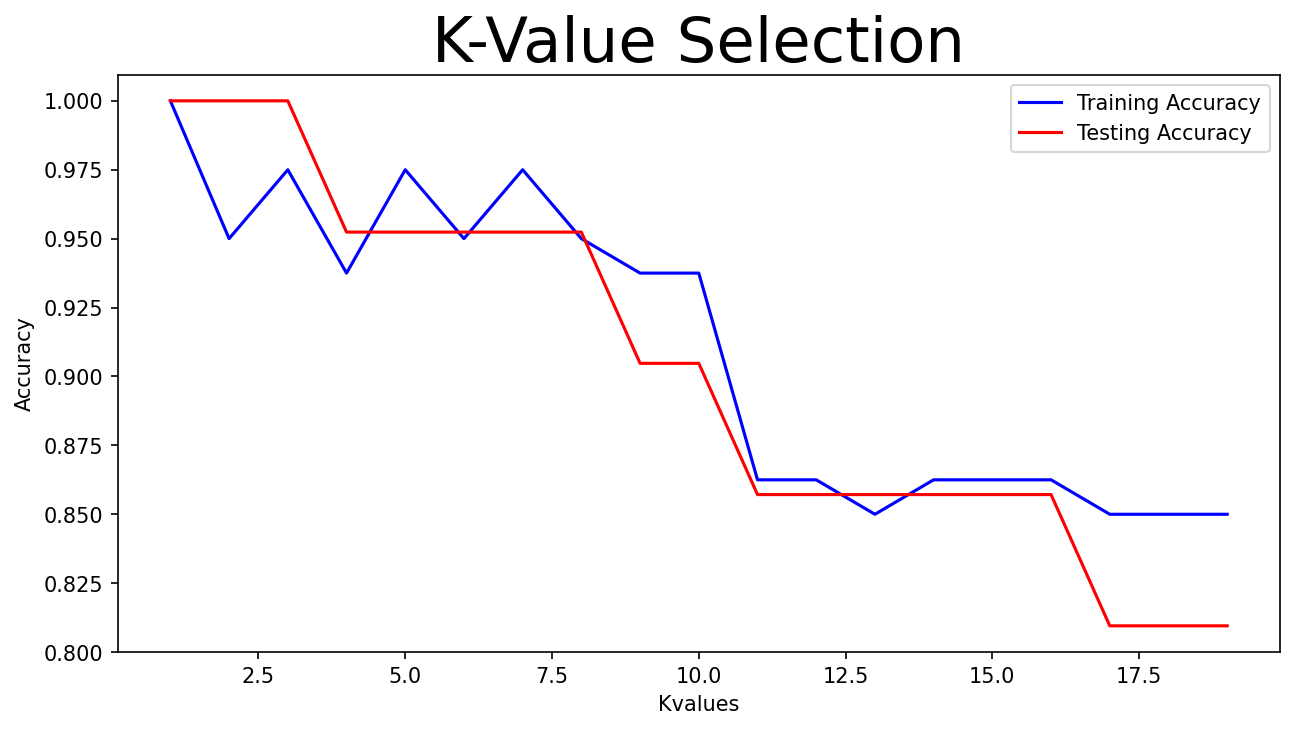

In [29]:
plt.plot(range(1,20),train_acc,color='blue',label='Training Accuracy')
plt.plot(range(1,20),test_acc,color='red',label='Testing Accuracy')
plt.xlabel('Kvalues')
plt.ylabel('Accuracy')
plt.title('K-Value Selection',size=30)
plt.legend()
plt.show()

In [30]:
model=KNeighborsClassifier(n_neighbors=3)
model.fit(xtrain,ytrain)
yk=model.predict(xtest)
print("Training Accuracy:",model.score(xtrain,ytrain))
print("Testing Accuracy:",model.score(xtest,ytest))

Training Accuracy: 0.975
Testing Accuracy: 1.0


In [31]:
accuracy_score(ytest,yk)

1.0

# 

Another way of Hyperparameter tuning

In [32]:
n_neighbors=np.array([2*i+1 for i in range(0,20)])
param_grid=dict(n_neighbors=n_neighbors)

In [33]:
param_grid

{'n_neighbors': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33,
        35, 37, 39])}

In [34]:
n_neighbors

array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33,
       35, 37, 39])

In [35]:
params={
    'n_neighbors':[1,  3,  5,  7,  9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33,
       35, 37, 39],
    'metric':['euclidean','manhattan']
}

In [36]:
model=KNeighborsClassifier()
grid=GridSearchCV(estimator=model,param_grid=params)
grid.fit(xtrain,ytrain)

C:\Users\Ankita\anaconda3\lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


GridSearchCV(estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21,
                                         23, 25, 27, 29, 31, 33, 35, 37, 39]})

In [37]:
print(grid.best_score_)
print(grid.best_params_)

0.9625
{'metric': 'euclidean', 'n_neighbors': 1}


In [38]:
model=KNeighborsClassifier(n_neighbors=1,metric='euclidean')
model.fit(xtrain,ytrain)

KNeighborsClassifier(metric='euclidean', n_neighbors=1)

In [39]:
y_predd=model.predict(xtest)

In [40]:
confusion_matrix(ytest,y_predd)

array([[12,  0,  0,  0,  0,  0],
       [ 0,  2,  0,  0,  0,  0],
       [ 0,  0,  1,  0,  0,  0],
       [ 0,  0,  0,  2,  0,  0],
       [ 0,  0,  0,  0,  3,  0],
       [ 0,  0,  0,  0,  0,  1]], dtype=int64)

In [41]:
print(classification_report(ytest,y_predd))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        12
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         2
           6       1.00      1.00      1.00         3
           7       1.00      1.00      1.00         1

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21



# Visualizing the CV result

In [42]:
from sklearn.metrics import accuracy_score
k_range=range(1,41)
k_scores=[]
for k in k_range:
    knn=KNeighborsClassifier(n_neighbors=k)
    knn.fit(xtrain,ytrain)
    ypred=knn.predict(xtest)
    acc=accuracy_score(ytest,ypred)
    k_scores.append(acc)
best_k_scores=pd.Series(k_scores,index=k_range).sort_values(ascending=False)
print(best_k_scores)

1     1.000000
3     1.000000
2     1.000000
4     0.952381
6     0.952381
7     0.952381
8     0.952381
5     0.952381
9     0.904762
10    0.904762
14    0.857143
16    0.857143
15    0.857143
13    0.857143
12    0.857143
11    0.857143
22    0.809524
26    0.809524
25    0.809524
24    0.809524
23    0.809524
21    0.809524
20    0.809524
19    0.809524
18    0.809524
17    0.809524
37    0.761905
36    0.761905
35    0.761905
34    0.761905
33    0.761905
32    0.761905
31    0.761905
30    0.761905
29    0.761905
28    0.761905
27    0.761905
38    0.714286
39    0.714286
40    0.714286
dtype: float64


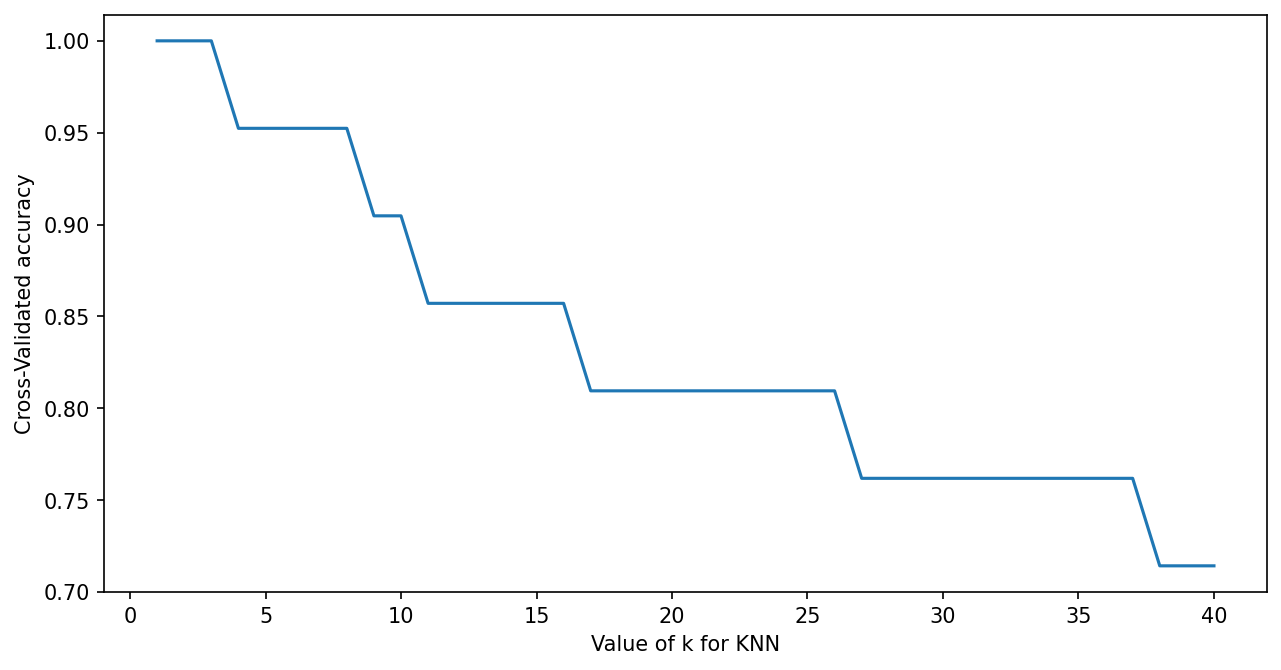

In [43]:
plt.plot(k_range,k_scores)
plt.xlabel('Value of k for KNN')
plt.ylabel('Cross-Validated accuracy')
plt.show()

# Interview questions